In [ ]:
# Import necessary libraries
import torch
import cv2
import numpy as np
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from PIL import Image
import plotly.graph_objects as go
from transformers import pipeline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import ndimage



In [6]:

# Define folder path and load images
folder = "../static/uploads/Chair/"
front_path = f"{folder}/front.jpg"
back_path = f"{folder}/back.jpg"
top_path = f"{folder}/top.jpg"


Running Advanced GrabCut with Shadow Detection...


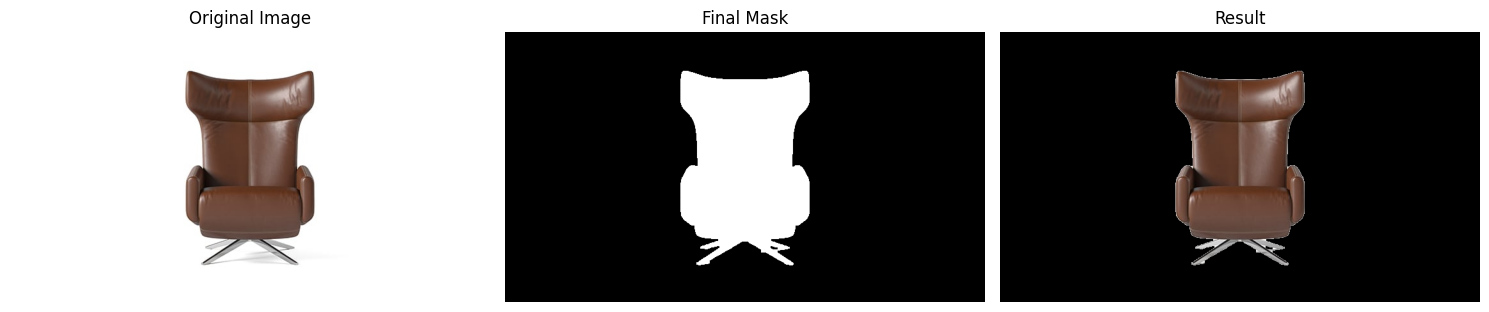

In [78]:
def advanced_grabcut_with_shadows(image_path):
    """
    Advanced GrabCut implementation with shadow detection and edge refinement.
    This function works best with light backgrounds but includes adaptations
    for handling shadows and complex edges.
    
    Args:
        image_path: Path to input image
    Returns:
        tuple: (original image, final mask, processed result)
    """
    def detect_shadows(img):
        # Convert to LAB color space where L channel represents lightness
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l_channel = lab[:,:,0]
        
        # Calculate local average of lightness
        blur = cv2.GaussianBlur(l_channel, (21, 21), 0)
        
        # Find regions darker than their surroundings
        shadow_mask = l_channel < (blur - 15)
        
        # Clean up the shadow mask
        kernel = np.ones((3,3), np.uint8)
        shadow_mask = cv2.morphologyEx(shadow_mask.astype(np.uint8), 
                                     cv2.MORPH_CLOSE, kernel)
        return shadow_mask

    def create_initial_mask(img):
        # Convert to HSV for better color handling
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        
        # Look at saturation and value channels
        s = hsv[:,:,1]
        v = hsv[:,:,2]
        
        # Create mask based on color properties
        mask = np.zeros(img.shape[:2], np.uint8)
        
        # Mark highly saturated or non-white areas as probable foreground
        mask[(s > 30) | (v < 240)] = cv2.GC_PR_FGD
        mask[(s <= 30) & (v >= 240)] = cv2.GC_PR_BGD
        
        return mask

    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Failed to load image from {image_path}")
    
    # Detect shadows
    shadow_mask = detect_shadows(image)
    
    # Create initial mask
    init_mask = create_initial_mask(image)
    
    # Mark shadow areas as probable background
    init_mask[shadow_mask == 1] = cv2.GC_PR_BGD
    
    # Define rectangle for GrabCut
    margin = 1
    rect = (margin, margin, 
            image.shape[1] - margin, 
            image.shape[0] - margin)
    
    # Apply GrabCut
    bgd_model = np.zeros((1,65), np.float64)
    fgd_model = np.zeros((1,65), np.float64)
    
    mask = init_mask.copy()
    cv2.grabCut(image, mask, rect, 
                bgd_model, fgd_model, 
                iterCount=8, 
                mode=cv2.GC_INIT_WITH_MASK)
    
    # Create binary mask
    final_mask = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
    
    # Final cleanup
    kernel = np.ones((3,3), np.uint8)
    final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel)
    final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_OPEN, kernel)
    
    # Create result
    result = image.copy()
    result[final_mask == 0] = [0, 0, 0]
    
    # Convert to RGB for display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    plt.subplot(131)
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(132)
    plt.imshow(final_mask, cmap='gray')
    plt.title('Final Mask')
    plt.axis('off')
    
    plt.subplot(133)
    plt.imshow(result_rgb)
    plt.title('Result')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return image_rgb, final_mask, result_rgb


# Example usage:
if __name__ == "__main__":
    image_path = "../static/uploads/Chair/front.jpg"
    
    print("Running Advanced GrabCut with Shadow Detection...")
    grabcut_results = advanced_grabcut_with_shadows(image_path)

Running Advanced GrabCut with Shadow Detection...


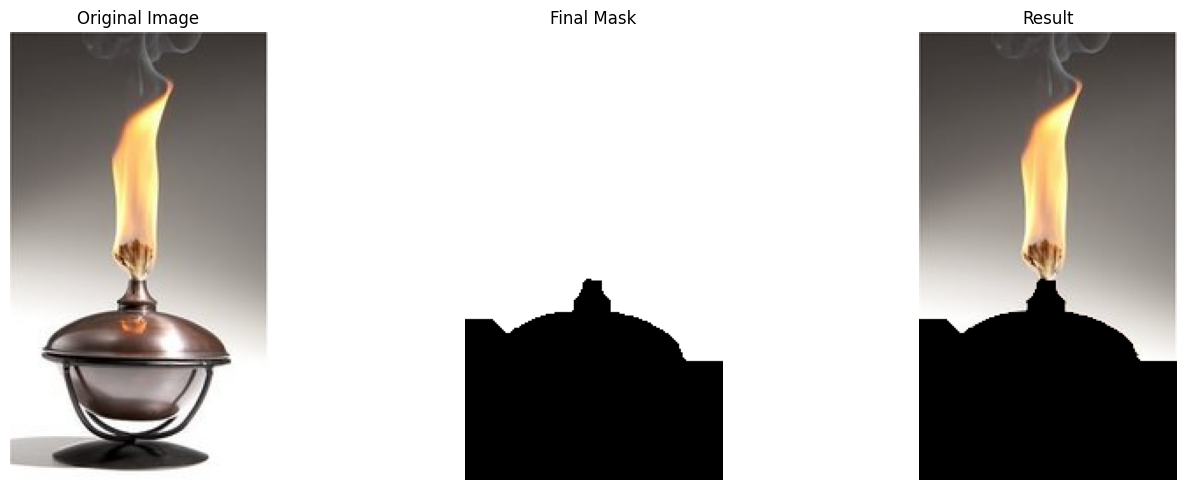

In [79]:
image_path = "../datasets/product_95/front.jpg"
    
print("Running Advanced GrabCut with Shadow Detection...")
grabcut_results = advanced_grabcut_with_shadows(image_path)

Running Advanced GrabCut with Shadow Detection and Edge Smoothing...


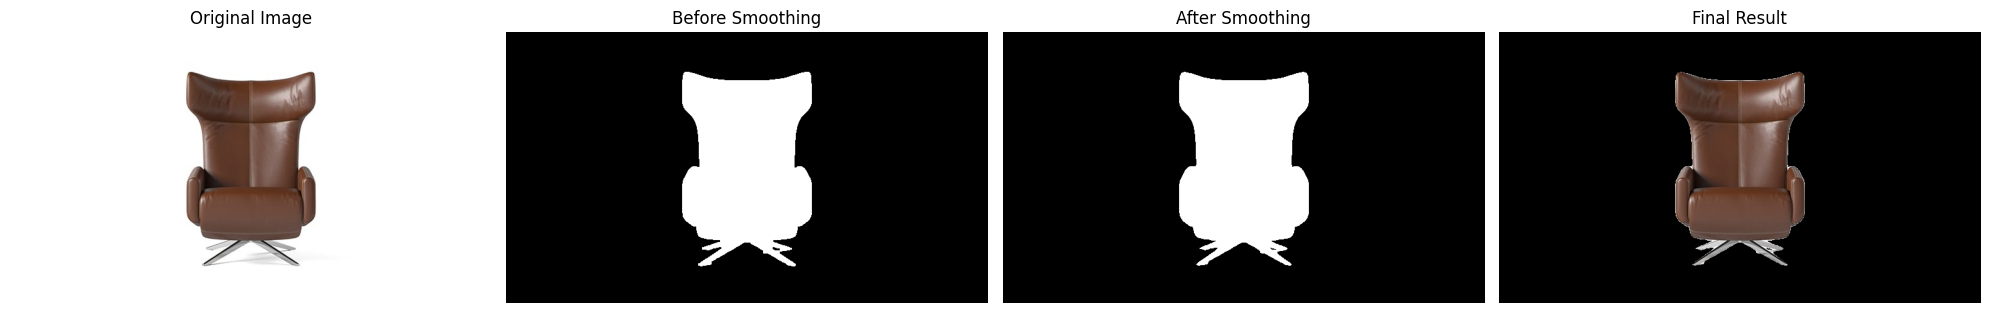

## Shadow improvement , color preservation with fixed background color

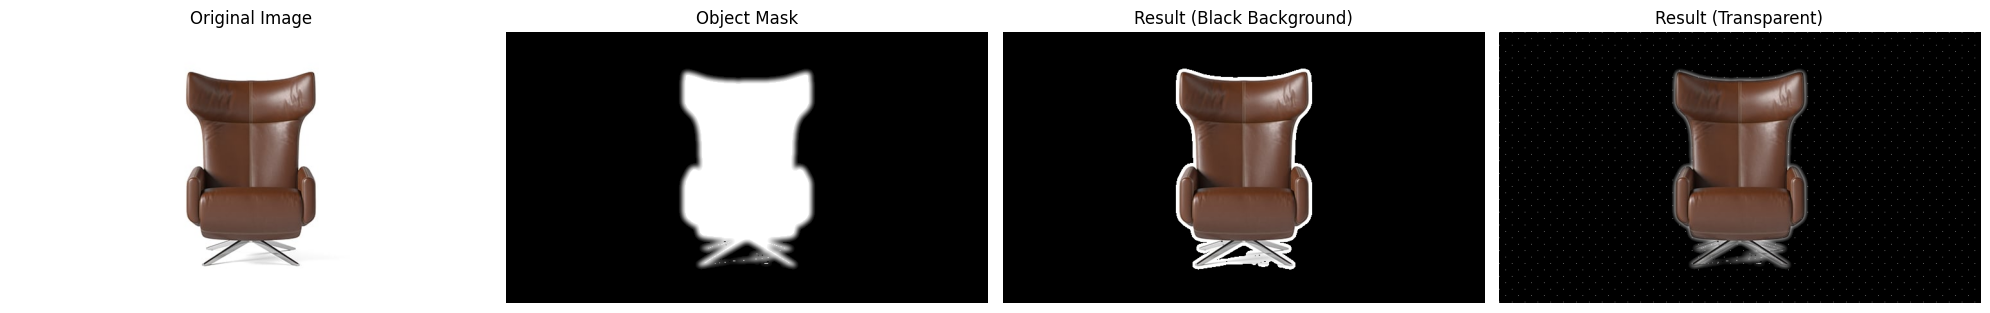

In [82]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def refined_background_removal(image_path, background_color=(255,255,255), edge_smoothing=5, preserve_whites=True):
    """
    Advanced background removal with improved edge handling and color preservation.
    
    Args:
        image_path: Path to input image
        background_color: RGB tuple indicating the background color to remove
        edge_smoothing: Amount of edge smoothing (higher = smoother)
        preserve_whites: Whether to preserve white colors in the object
    """
    def create_color_range_mask(img, target_color, tolerance=30):
        """Create a mask for colors within tolerance of target color"""
        lower_bound = np.array([max(0, c - tolerance) for c in target_color])
        upper_bound = np.array([min(255, c + tolerance) for c in target_color])
        return cv2.inRange(img, lower_bound, upper_bound)

    def smooth_edges(mask, smooth_factor):
        """Apply sophisticated edge smoothing"""
        # Convert binary mask to float for better gradient computation
        mask_float = mask.astype(np.float32) / 255.0
        
        # Apply gaussian blur for initial smoothing
        blurred = cv2.GaussianBlur(mask_float, (smooth_factor*2+1, smooth_factor*2+1), 0)
        
        # Create gradient mask for edge detection
        gradient_x = cv2.Sobel(blurred, cv2.CV_32F, 1, 0, ksize=3)
        gradient_y = cv2.Sobel(blurred, cv2.CV_32F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(gradient_x**2 + gradient_y**2)
        
        # Smooth only the edges
        edge_mask = (gradient_magnitude > 0.1).astype(np.float32)
        smoothed_edges = cv2.GaussianBlur(mask_float, (smooth_factor*4+1, smooth_factor*4+1), 0)
        result = np.where(edge_mask, smoothed_edges, mask_float)
        
        return (result * 255).astype(np.uint8)

    def detect_shadows_improved(img, background):
        """Improved shadow detection that preserves object details"""
        # Convert to LAB color space
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        bg_lab = cv2.cvtColor(background, cv2.COLOR_BGR2LAB)
        
        # Compare L channel differences
        l_diff = np.abs(lab[:,:,0].astype(np.float32) - bg_lab[:,:,0].astype(np.float32))
        
        # Create shadow mask with adaptive threshold
        shadow_threshold = np.mean(l_diff) * 0.5
        shadow_mask = l_diff < shadow_threshold
        
        # Don't mark areas with significant color as shadows
        color_diff = np.sum(np.abs(lab[:,:,1:] - bg_lab[:,:,1:]), axis=2)
        shadow_mask &= (color_diff < 30)
        
        return shadow_mask.astype(np.uint8)

    def preserve_white_details(img, mask, threshold=245):
        """Preserve white details in the object"""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        white_areas = gray > threshold
        
        # Only preserve whites that are connected to non-white object parts
        kernel = np.ones((3,3), np.uint8)
        dilated_mask = cv2.dilate(mask, kernel, iterations=2)
        preserved_whites = white_areas & dilated_mask
        
        return mask | preserved_whites

    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Failed to load image from {image_path}")
    
    # Create background image
    background = np.full_like(image, background_color[::-1])  # BGR format
    
    # Create initial mask using color range
    color_mask = create_color_range_mask(image, background_color[::-1])
    
    # Detect shadows with improved method
    shadow_mask = detect_shadows_improved(image, background)
    
    # Combine masks
    combined_mask = (color_mask | shadow_mask)
    
    # Invert mask (we want to keep the object, not the background)
    object_mask = cv2.bitwise_not(combined_mask)
    
    # Preserve white details if requested
    if preserve_whites:
        object_mask = preserve_white_details(image, object_mask)
    
    # Apply edge smoothing
    if edge_smoothing > 0:
        object_mask = smooth_edges(object_mask, edge_smoothing)
    
    # Create alpha channel
    alpha = object_mask
    
    # Create output image with alpha channel
    rgba = cv2.cvtColor(image, cv2.COLOR_BGR2BGRA)
    rgba[:, :, 3] = alpha
    
    # Create visualization result (black background)
    result = image.copy()
    result[alpha == 0] = [0, 0, 0]
    
    # Convert to RGB for display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    
    # Visualization
    plt.figure(figsize=(20, 5))
    
    plt.subplot(141)
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(142)
    plt.imshow(object_mask, cmap='gray')
    plt.title('Object Mask')
    plt.axis('off')
    
    plt.subplot(143)
    plt.imshow(result_rgb)
    plt.title('Result (Black Background)')
    plt.axis('off')
    
    # Display with checkered background to show transparency
    plt.subplot(144)
    checkered = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    checkered[::20, ::20] = [200, 200, 200]
    checkered[10::20, 10::20] = [200, 200, 200]
    
    # Blend with alpha
    alpha_3d = alpha[:,:,np.newaxis] / 255.0
    blended = (image_rgb * alpha_3d + checkered * (1 - alpha_3d)).astype(np.uint8)
    plt.imshow(blended)
    plt.title('Result (Transparent)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return image_rgb, alpha, result_rgb, rgba

# Example usage:
if __name__ == "__main__":
    # You can customize these parameters
    results = refined_background_removal(
        "../static/uploads/Chair/front.jpg",
        background_color=(255, 255, 255),  # White background
        edge_smoothing=5,                  # Edge smoothing factor
        preserve_whites=True               # Preserve white details
    )

Loading image...
Creating masks...
Preserving white details...
Smoothing edges...


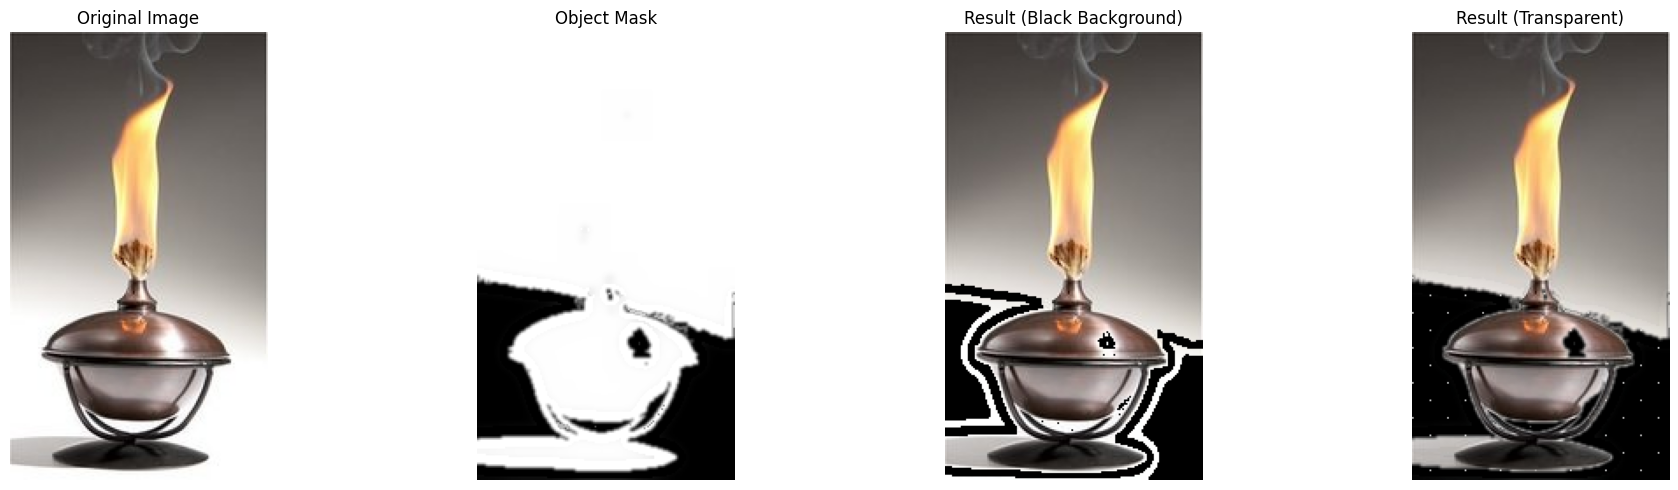

In [93]:
results = refined_background_removal(
        "../datasets/product_95/front.jpg",
        background_color=(255, 255, 255),  # White background
        edge_smoothing=5,                  # Edge smoothing factor
        preserve_whites=True               # Preserve white details
    )

## Shadow improvement , color preservation with fixed background color with Auto background detection

Loading image...
Detecting background color...
Detected background color (RGB): (255, 255, 255)
Detecting shadows...
Creating color-based mask...
Preserving white details...
Smoothing edges...


c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1474: ConvergenceWarning:

Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.



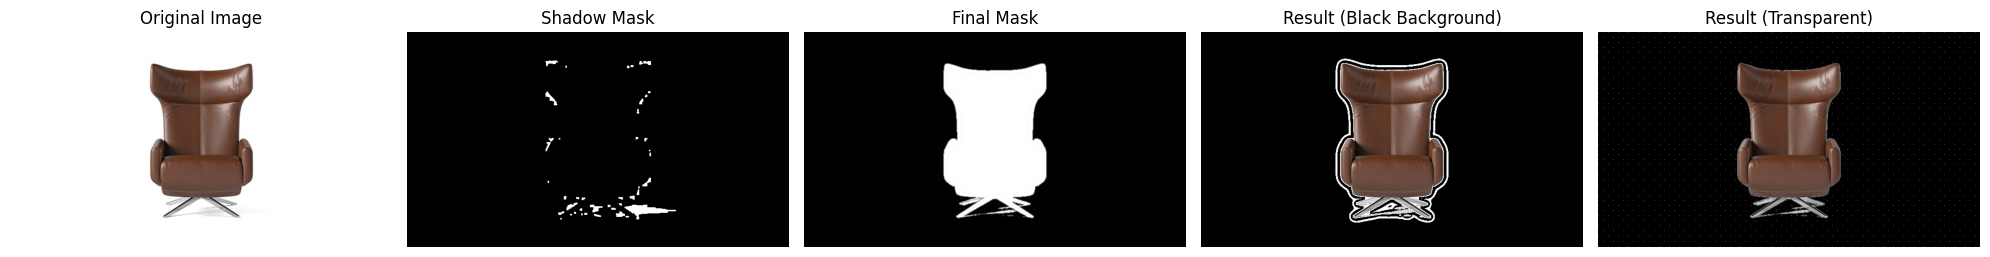

In [111]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def detect_background_color(img, samples_per_edge=100):
    """
    Safely detect the background color by analyzing image edges.
    Uses a more robust sampling approach that avoids zero-step slicing.
    
    Args:
        img: Input image in BGR format
        samples_per_edge: Number of samples to take from each edge
        
    Returns:
        tuple: RGB color values of detected background
    """
    height, width = img.shape[:2]
    
    # Ensure we take at least one sample per edge
    samples_per_edge = max(1, min(samples_per_edge, min(height, width)))
    
    # Calculate step sizes (ensure non-zero)
    width_step = max(1, width // samples_per_edge)
    height_step = max(1, height // samples_per_edge)
    
    # Sample pixels from edges
    edge_pixels = []
    
    # Sample top and bottom edges
    for x in range(0, width, width_step):
        edge_pixels.append(img[0, x])        # Top edge
        edge_pixels.append(img[-1, x])       # Bottom edge
    
    # Sample left and right edges
    for y in range(0, height, height_step):
        edge_pixels.append(img[y, 0])        # Left edge
        edge_pixels.append(img[y, -1])       # Right edge
    
    # Convert to numpy array
    edge_pixels = np.array(edge_pixels)
    
    # Use K-means clustering to find dominant color
    kmeans = KMeans(n_clusters=3, n_init=10)
    kmeans.fit(edge_pixels)
    
    # Get the most frequent color cluster
    unique, counts = np.unique(kmeans.labels_, return_counts=True)
    dominant_cluster = unique[np.argmax(counts)]
    background_color = kmeans.cluster_centers_[dominant_cluster].astype(int)
    
    # Convert from BGR to RGB
    return tuple(background_color[::-1])

def detect_shadows_enhanced(img, background_color):
    """
    Enhanced shadow detection that preserves subtle lighting transitions and reflections.
    This function analyzes both global and local lighting patterns to identify shadows
    while being careful not to misclassify object details as shadows.
    
    Args:
        img: Input image in BGR format
        background_color: RGB tuple of the background color
    Returns:
        numpy.ndarray: Shadow mask where 1 indicates shadow pixels
    """
    # First, convert background color from RGB to BGR for OpenCV
    bg_color = background_color[::-1]
    
    # Create a background image matching our detected background color
    background = np.full_like(img, bg_color)
    
    # Convert both images to LAB color space for better lighting analysis
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    bg_lab = cv2.cvtColor(background, cv2.COLOR_BGR2LAB)
    
    # Extract L (lightness) channels
    l_img = lab[:,:,0].astype(np.float32)
    l_bg = bg_lab[:,:,0].astype(np.float32)
    
    # Calculate local average of lightness using multiple scales
    shadow_masks = []
    for kernel_size in [(21, 21), (41, 41)]:  # Multiple scales for different shadow sizes
        # Calculate local lightness average
        local_mean = cv2.GaussianBlur(l_img, kernel_size, 0)
        
        # Calculate lightness difference from background
        l_diff = np.abs(l_img - l_bg)
        local_diff = np.abs(local_mean - l_bg)
        
        # Create adaptive threshold based on local contrast
        threshold = np.mean(l_diff) * 0.5 + local_diff * 0.2
        
        # Identify shadow regions
        shadow = (l_diff < threshold) & (l_img < l_bg)
        shadow_masks.append(shadow)
    
    # Combine shadow masks from different scales
    shadow_mask = np.logical_or.reduce(shadow_masks)
    
    # Analyze color differences to prevent misclassifying colored regions as shadows
    a_diff = np.abs(lab[:,:,1] - bg_lab[:,:,1])
    b_diff = np.abs(lab[:,:,2] - bg_lab[:,:,2])
    color_diff = np.sqrt(a_diff**2 + b_diff**2)
    
    # Only keep shadow pixels where color difference is small
    shadow_mask &= (color_diff < 30)
    
    # Clean up the mask
    kernel = np.ones((3,3), np.uint8)
    shadow_mask = cv2.morphologyEx(shadow_mask.astype(np.uint8), 
                                 cv2.MORPH_CLOSE, kernel)
    shadow_mask = cv2.morphologyEx(shadow_mask.astype(np.uint8), 
                                 cv2.MORPH_OPEN, kernel)
    
    return shadow_mask
def refined_background_removal(image_path, background_color=None, edge_smoothing=5, preserve_whites=True):
    """
    Advanced background removal with automatic background color detection and
    improved edge handling.
    
    Args:
        image_path: Path to input image
        background_color: RGB tuple or None for auto-detection
        edge_smoothing: Amount of edge smoothing (higher = smoother)
        preserve_whites: Whether to preserve white colors in the object
    """
    def create_color_range_mask(img, target_color, tolerance=30):
        """Create an adaptive mask for colors within tolerance of target color"""
        # Convert target color from RGB to BGR
        target_bgr = target_color[::-1]
        
        # Create bounds with tolerance
        lower_bound = np.array([max(0, c - tolerance) for c in target_bgr])
        upper_bound = np.array([min(255, c + tolerance) for c in target_bgr])
        
        return cv2.inRange(img, lower_bound, upper_bound)

    def smooth_edges(mask, smooth_factor):
        """Apply sophisticated edge smoothing with gradient preservation"""
        # Convert to float for better precision
        mask_float = mask.astype(np.float32) / 255.0
        
        # Multi-scale smoothing
        smoothed = np.zeros_like(mask_float)
        weights_sum = 0
        
        # Apply multiple scales of smoothing
        for i in range(1, 4):
            kernel_size = smooth_factor * 2 * i + 1
            current_smooth = cv2.GaussianBlur(mask_float, 
                                            (kernel_size, kernel_size), 
                                            0)
            weight = 1.0 / i
            smoothed += current_smooth * weight
            weights_sum += weight
        
        smoothed /= weights_sum
        
        # Edge-aware blending
        gradient_x = cv2.Sobel(smoothed, cv2.CV_32F, 1, 0, ksize=3)
        gradient_y = cv2.Sobel(smoothed, cv2.CV_32F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(gradient_x**2 + gradient_y**2)
        
        edge_mask = (gradient_magnitude > 0.1).astype(np.float32)
        result = np.where(edge_mask, 
                         cv2.GaussianBlur(mask_float, (3, 3), 0),
                         smoothed)
        
        return (result * 255).astype(np.uint8)

    def preserve_white_details(img, mask, threshold=245):
        """Preserve white details with connectivity analysis"""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Create adaptive threshold
        local_mean = cv2.GaussianBlur(gray, (15, 15), 0)
        local_threshold = threshold - (255 - local_mean) * 0.1
        white_areas = gray > local_threshold
        
        # Connect to main object
        kernel = np.ones((3,3), np.uint8)
        dilated_mask = cv2.dilate(mask, kernel, iterations=2)
        preserved_whites = white_areas & dilated_mask
        
        # Clean up artifacts
        preserved_whites = cv2.morphologyEx(preserved_whites.astype(np.uint8), 
                                          cv2.MORPH_CLOSE, kernel)
        
        return mask | preserved_whites

    # Main processing pipeline
    try:
        print("Loading image...")
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image from {image_path}")
        
        # Handle background color detection
        if background_color is None:
            print("Detecting background color...")
            detected_color = detect_background_color(image)
            print(f"Detected background color (RGB): {detected_color}")
            bg_color = detected_color
        else:
            bg_color = background_color
        
        # Create background image and masks
        background = np.full_like(image, bg_color[::-1])  # Convert to BGR
        
        print("Detecting shadows...")
        shadow_mask = detect_shadows_enhanced(image, bg_color)
        
        print("Creating color-based mask...")
        color_mask = create_color_range_mask(image, bg_color)
        
        # Combine color and shadow masks
        combined_mask = (color_mask | shadow_mask)
        
        # Invert mask (we want to keep the object, not the background)
        object_mask = cv2.bitwise_not(combined_mask)
        
        # Preserve white details if requested
        if preserve_whites:
            print("Preserving white details...")
            object_mask = preserve_white_details(image, object_mask)
        
        # Apply edge smoothing
        if edge_smoothing > 0:
            print("Smoothing edges...")
            object_mask = smooth_edges(object_mask, edge_smoothing)
        
        # Create output images
        alpha = object_mask
        rgba = cv2.cvtColor(image, cv2.COLOR_BGR2BGRA)
        rgba[:, :, 3] = alpha
        
        result = image.copy()
        result[alpha == 0] = [0, 0, 0]
        
        # Convert to RGB for display
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
        
        # Enhanced visualization to show shadow detection
        plt.figure(figsize=(20, 5))
        
        plt.subplot(151)
        plt.imshow(image_rgb)
        plt.title('Original Image')
        plt.axis('off')
        
        plt.subplot(152)
        plt.imshow(shadow_mask, cmap='gray')
        plt.title('Shadow Mask')
        plt.axis('off')
        
        plt.subplot(153)
        plt.imshow(object_mask, cmap='gray')
        plt.title('Final Mask')
        plt.axis('off')
        
        plt.subplot(154)
        plt.imshow(result_rgb)
        plt.title('Result (Black Background)')
        plt.axis('off')
        
        # Display with checkered background
        plt.subplot(155)
        checkered = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        checkered[::20, ::20] = [200, 200, 200]
        checkered[10::20, 10::20] = [200, 200, 200]
        
        alpha_3d = alpha[:,:,np.newaxis] / 255.0
        blended = (image_rgb * alpha_3d + checkered * (1 - alpha_3d)).astype(np.uint8)
        plt.imshow(blended)
        plt.title('Result (Transparent)')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        return image_rgb, alpha, result_rgb, rgba
        
    except Exception as e:
        print(f"Error during processing: {str(e)}")
        return None

# Example usage:
if __name__ == "__main__":
    try:
        results = refined_background_removal(
            "../static/uploads/Chair/front.jpg",
            background_color=None,  # Enable auto-detection
            edge_smoothing=5,
            preserve_whites=True
        )
    except Exception as e:
        print(f"Failed to process image: {str(e)}")

Loading image...
Detecting background color...
Detected background color (RGB): (255, 254, 255)
Detecting shadows...
Creating color-based mask...
Preserving white details...
Smoothing edges...


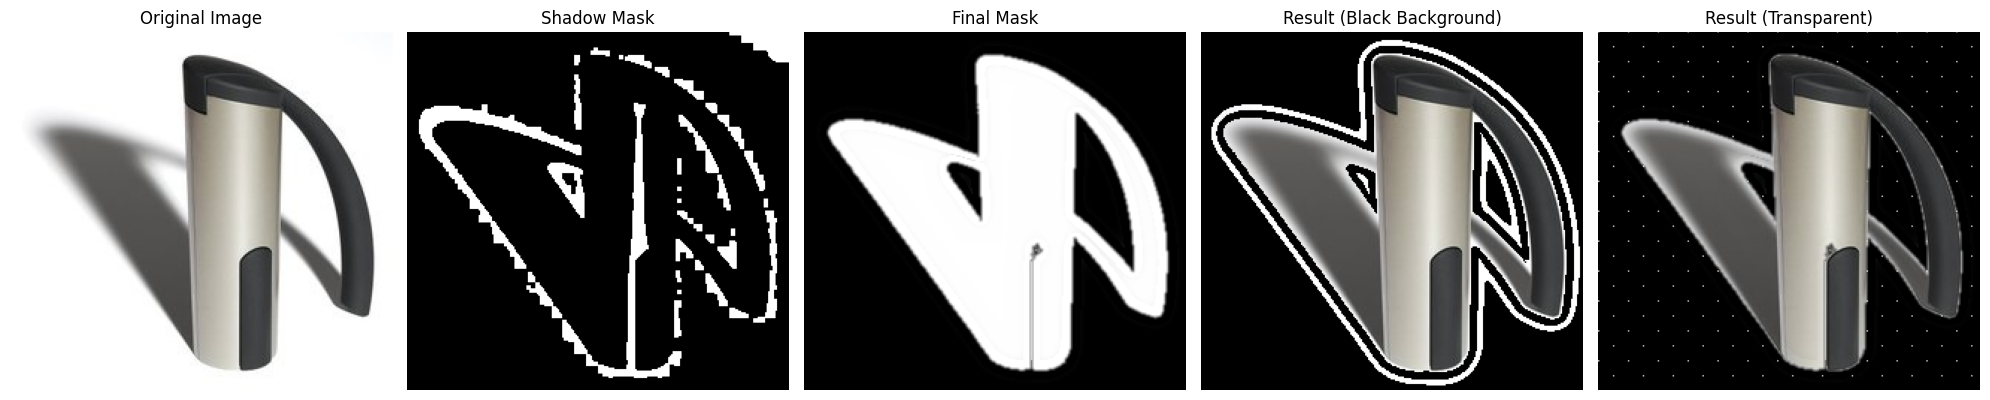

In [112]:
# Example usage:
if __name__ == "__main__":
    try:
        results = refined_background_removal(
            "../datasets/product_114/back.jpg",
            background_color=None,  # Enable auto-detection
            edge_smoothing=5,
            preserve_whites=True
        )
    except Exception as e:
        print(f"Failed to process image: {str(e)}")

In [36]:
def create_object_mesh(image_input, depth_threshold=0.75):
    print("Image type:", image_input.__class__)
    
    # Step 1: Convert input to numpy array with proper format
    if isinstance(image_input, str):
        # Loading from file path
        image = cv2.imread(image_input)
        if image is None:
            raise ValueError(f"Failed to load image from path: {image_input}")
    elif isinstance(image_input, Image.Image):
        # Convert PIL Image to numpy array
        # First convert to RGB numpy array
        image_array = np.array(image_input)
        # Then convert from RGB to BGR for OpenCV
        image = cv2.cvtColor(image_array, cv2.COLOR_RGB2BGR)
    else:
        # Assume it's already a numpy array
        image = image_input
    
    # Step 2: Verify array format
    if not isinstance(image, np.ndarray):
        raise TypeError("Image must be converted to numpy array")
    if len(image.shape) != 3:
        raise ValueError("Image must be a 3-channel color image")
    
    # Step 3: Convert to grayscale
    try:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    except cv2.error as e:
        print("Error during color conversion. Image shape:", image.shape)
        print("Image dtype:", image.dtype)
        raise ValueError("Failed to convert image to grayscale") from e
    
    # Step 4: Visualize grayscale image
    plt.figure(figsize=(15, 5))
    plt.imshow(image_gray, cmap='gray')  # Specify colormap for grayscale
    plt.title('Grayscale Image')
    plt.show()
    
    # Step 5: Edge detection
    try:
        edges = cv2.Canny(image_gray, 100, 200)
        kernel = np.ones((5, 5), np.uint8)
        dilated_edges = cv2.dilate(edges, kernel, iterations=1)
    except cv2.error as e:
        print("Error during edge detection. Grayscale image shape:", image_gray.shape)
        print("Grayscale image dtype:", image_gray.dtype)
        raise ValueError("Failed during edge detection") from e
    
    contours, _ = cv2.findContours(dilated_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return None
        
    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros(image_gray.shape, dtype=np.uint8)
    cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    mask_blurred = cv2.GaussianBlur(mask, (1, 1), 0)
    
    output_image = np.zeros_like(image)
    output_image[mask_blurred > 0] = image[mask_blurred > 0]
    
    # Get depth map using Depth Anything model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    depth_model = pipeline("depth-estimation", model="depth-anything/Depth-Anything-V2-base-hf", device=device)
    
    # Convert to PIL Image for depth estimation
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image_rgb)
    depth_predictions = depth_model(image_pil)
    depth_map = np.array(depth_predictions["depth"])

    # Add this section
    
    # depth_map = integrate_foreground_processing(image, depth_map)
    
    # Process depth map
    height, width, _ = output_image.shape
    depth_map_resized = cv2.resize(depth_map, (width, height))
    
    # Apply mask to depth map
    mask_resized = cv2.resize(mask, (depth_map_resized.shape[1], depth_map_resized.shape[0]))
    mask_contour = mask_resized > 0
    depth_edges = np.zeros_like(depth_map_resized)
    depth_edges[mask_contour] = depth_map_resized[mask_contour]
    depth_edges_smoothed = cv2.GaussianBlur(depth_edges, (5, 5), 0)
    
    # Normalize depth values
    depth_norm = (depth_edges_smoothed - depth_edges_smoothed.min()) / (depth_edges_smoothed.max() - depth_edges_smoothed.min())
    
    # Convert to RGB for visualization
    output_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)
    
    # Create coordinate grids
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
    
    # Flatten arrays
    x_coords_flat = x_coords.ravel().tolist()
    y_coords_flat = y_coords.ravel().tolist()
    z_coords_flat = depth_norm.ravel().tolist()
    colors_flat = output_rgb.reshape(-1, 3).tolist()
    
    # Apply depth threshold and create mask for valid points
    mask = []
    for z, color in zip(z_coords_flat, colors_flat):
        is_valid = (z > depth_threshold) and not (color[0] == 0 and color[1] == 0 and color[2] == 0)
        mask.append(is_valid)
    
    # Filter points based on mask
    x_filtered = [x for x, m in zip(x_coords_flat, mask) if m]
    y_filtered = [y for y, m in zip(y_coords_flat, mask) if m]
    z_filtered = [z for z, m in zip(z_coords_flat, mask) if m]
    colors_filtered = [c for c, m in zip(colors_flat, mask) if m]
    
    # Create the Plotly figure
    fig = go.Figure(data=[go.Scatter3d(
        x=x_filtered,
        y=y_filtered,
        z=z_filtered,
        mode='markers',
        marker=dict(
            size=2,
            color=[f'rgb({r}, {g}, {b})' for r, g, b in colors_filtered],
            opacity=1
        )
    )])
    
    # Update layout
    fig.update_layout(
        scene=dict(
            xaxis=dict(nticks=10, range=[0, width]),
            yaxis=dict(nticks=10, range=[0, height]),
            zaxis=dict(nticks=10, range=[0, max(z_filtered)]),
        ),
        margin=dict(l=0, r=0, b=0, t=30)
    )
    
    return fig


def combine_front_back_meshes(front_fig, back_fig, depth_threshold=0.25, sampling_rate=0.5):
    """
    Creates an optimized 3D visualization combining front and back mesh views.
    
    Args:
        front_fig: Plotly figure of front mesh
        back_fig: Plotly figure of back mesh
        depth_threshold: Depth threshold value
        sampling_rate: Fraction of points to keep (0.0 to 1.0)
    """
    def extract_points(fig):
        if fig is None or not fig.data:
            return [], [], [], []
        trace = fig.data[0]
        return (
            np.array(trace.x), 
            np.array(trace.y), 
            np.array(trace.z), 
            [c.strip('rgb()').split(',') for c in trace.marker.color]
        )
    
    def sample_points(x, y, z, colors, rate):
        """Efficiently sample points using numpy"""
        n_points = len(x)
        n_sample = int(n_points * rate)
        if n_sample >= n_points:
            return x, y, z, colors
        
        # Use numpy's random choice for efficient sampling
        indices = np.random.choice(n_points, n_sample, replace=False)
        indices.sort()  # Sort for better memory access patterns
        
        return (x[indices], y[indices], z[indices],
                [colors[i] for i in indices])
    
    # Extract points and convert to numpy arrays for faster processing
    front_x, front_y, front_z, front_colors = extract_points(front_fig)
    back_x, back_y, back_z, back_colors = extract_points(back_fig)
    
    # Sample points if needed
    front_x, front_y, front_z, front_colors = sample_points(
        front_x, front_y, front_z, front_colors, sampling_rate)
    back_x, back_y, back_z, back_colors = sample_points(
        back_x, back_y, back_z, back_colors, sampling_rate)
    
    # Calculate dimensions using numpy operations
    original_width = max(np.max(front_x), np.max(back_x))
    original_height = max(np.max(front_y), np.max(back_y))
    aspect_ratio = original_width / original_height
    
    # Center views using vectorized operations
    front_width = np.max(front_x) - np.min(front_x)
    back_width = np.max(back_x) - np.min(back_x)
    
    front_x_centered = front_x - np.min(front_x) - front_width/2
    back_x_centered = -(back_x - np.min(back_x) - back_width/2)
    
    # Normalize z-coordinates using vectorized operations
    front_z_norm = 0.5 + (front_z - np.min(front_z)) * depth_threshold / (np.max(front_z) - np.min(front_z))
    back_z_norm = 0.5 - (back_z - np.min(back_z)) * depth_threshold / (np.max(back_z) - np.min(back_z))
    
    # Convert colors to RGB strings efficiently
    def process_colors(colors):
        return [f'rgb({",".join(c)})' for c in colors]
    
    front_colors_processed = process_colors(front_colors)
    back_colors_processed = process_colors(back_colors)
    
    # Combine points using numpy concatenation
    combined_x = np.concatenate([front_x_centered, back_x_centered])
    combined_y = np.concatenate([front_y, back_y])
    combined_z = np.concatenate([front_z_norm, back_z_norm])
    combined_colors = front_colors_processed + back_colors_processed
    
    # Create the figure
    combined_fig = go.Figure(data=[go.Scatter3d(
        x=combined_x,
        y=combined_y,
        z=combined_z,
        mode='markers',
        marker=dict(
            size=2,
            color=combined_colors,
            opacity=1
        ),
        showlegend=False
    )])
    
    # Update layout with minimal settings
    combined_fig.update_layout(
        scene=dict(
            aspectratio=dict(x=1, y=1/aspect_ratio, z=0.5),
            aspectmode='manual',
            camera=dict(
                eye=dict(x=1.25, y=-0.25, z=1.25),
                up=dict(x=0, y=0, z=0),
                center=dict(x=0, y=0, z=0)
            ),
            xaxis=dict(
                range=[-original_width/2, original_width/2],
                showticklabels=False, showgrid=False,
                zeroline=False, showline=False, showbackground=False
            ),
            yaxis=dict(
                range=[0, original_height],
                showticklabels=False, showgrid=False,
                zeroline=False, showline=False, showbackground=False
            ),
            zaxis=dict(
                range=[0, 1],
                showticklabels=False, showgrid=False,
                zeroline=False, showline=False, showbackground=False
            )
        ),
        uirevision='true',
        showlegend=False,
        margin=dict(l=0, r=0, t=0, b=0, pad=0),
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)'
    )
    
    return combined_fig



def process_orthogonal_views(front, back=None, top=None, depth_threshold=0.25, sampling_rate=1.0):
    # Process all three views
    image_paths = {
        'front': f"{front}",
        'back': f"{back}",
        'top': f"{top}"
    }

    # First normalize all images
    try:
        
        # Load and resize images
        front_img = load_and_normalize_images(front_path)
        back_img = load_and_normalize_images(back_path)
        top_img = load_and_normalize_images(top_path)

        # Plot original images
        plt.figure(figsize=(15, 5))
        plt.subplot(131)
        plt.imshow(front_img)
        plt.title('Front View')
        plt.subplot(132)
        plt.imshow(back_img)
        plt.title('Back View')
        plt.subplot(133)
        plt.imshow(top_img)
        plt.title('Top View')
        plt.show()
        print("\nAll images successfully normalized to size:")

        # First, let's get our three normalized meshes individually
        front_fig = create_object_mesh(front_img, depth_threshold=depth_threshold)
        back_fig = create_object_mesh(back_img, depth_threshold=depth_threshold)
        top_fig = create_object_mesh(top_img, depth_threshold=depth_threshold)

         # For maximum quality (but slower)
        combined_mesh = combine_front_back_meshes(front_fig, back_fig, sampling_rate=sampling_rate)
        return combined_mesh.to_dict()
    
    except Exception as e:
        print(f"Error during image normalization: {str(e)}")
        return None

In [41]:
# Define folder path and load images
folder = "../static/uploads/Chair/"
front_path = f"{folder}/front.jpg"
back_path = f"{folder}/back.jpg"
top_path = f"{folder}/top.jpg"


# figure = process_orthogonal_views(front_path, back_path, top_path)

results = extract_features_and_remove_background(front_path, visualize=True)


C:\Users\ACER\AppData\Local\Temp\ipykernel_5084\2390743973.py:137: DeprecationWarning:

`np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)



TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'